In [2]:
import os
from dotenv import load_dotenv
import requests
import pandas as pd

load_dotenv()
USER = os.getenv("BCCH_USER")
PASSWORD = os.getenv("BCCH_PASSWORD")

print(f"Usuario cargado: {USER}")
print(f"Password cargado: {'sí' if PASSWORD else 'NO'}")


Usuario cargado: nicolas.sanchezh01@gmail.com
Password cargado: sí


In [ ]:
BASE_URL = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"

params = {
    "user": USER,
    "pass": PASSWORD,
    "function": "GetSeries",
    "timeseries": "F073.TCO.PRE.Z.D", # Tipo de cambio USD/CLP
    "firstdate": "2024-01-01",
    "lastdate": "2024-01-31",
}

response = requests.get(BASE_URL, params=params)
response.raise_for_status()
data = response.json()

print(f"Código de respuesta HTTP: {response.status_code}")
print(f"Código BCCh: {data['Codigo']}")
print(f"Descripción: {data['Descripcion']}")
print(f"Serie: {data['Series']['descripEsp']}")
print(f"Cantidad de observaciones: {len(data['Series']['Obs'])}")

Código de respuesta HTTP: 200
Código BCCh: 0
Descripción: Success
Serie: Tipo de cambio nominal (dólar observado $CLP/USD); tipo de cambio; ; precio; diario; ; Banco Central de Chile; ; 
Cantidad de observaciones: 30


In [4]:
obs = data['Series']['Obs']
print("Primer registro:", obs[0])
print("Último registro:", obs[-1])
print(f"\nTipo del campo 'value': {type(obs[0]['value']).__name__}")

Primer registro: {'indexDateString': '02-01-2024', 'value': '877.12', 'statusCode': 'OK'}
Último registro: {'indexDateString': '31-01-2024', 'value': '932.66', 'statusCode': 'OK'}

Tipo del campo 'value': str


In [9]:
df = pd.DataFrame(obs).rename(columns={"indexDateString": "Fecha dato","value":"Valor"})
print("Tipos originales:")
print(df.dtypes)
df["Fecha dato"]=pd.to_datetime(df["Fecha dato"],format="%d-%m-%Y")
df["Valor"]=pd.to_numeric(df["Valor"],errors="coerce")

print(df.dtypes)

Tipos originales:
Fecha dato    str
Valor         str
statusCode    str
dtype: object
Fecha dato    datetime64[us]
Valor                float64
statusCode               str
dtype: object


In [10]:
df.head()

,Fecha dato,Valor,statusCode
0,2024-01-02,877.12,OK
1,2024-01-03,880.92,OK
2,2024-01-04,884.39,OK
3,2024-01-05,884.45,OK
4,2024-01-06,NaN,ND


<Axes: title={'center': 'USD/CLP - Enero 2024'}, xlabel='Fecha dato'>

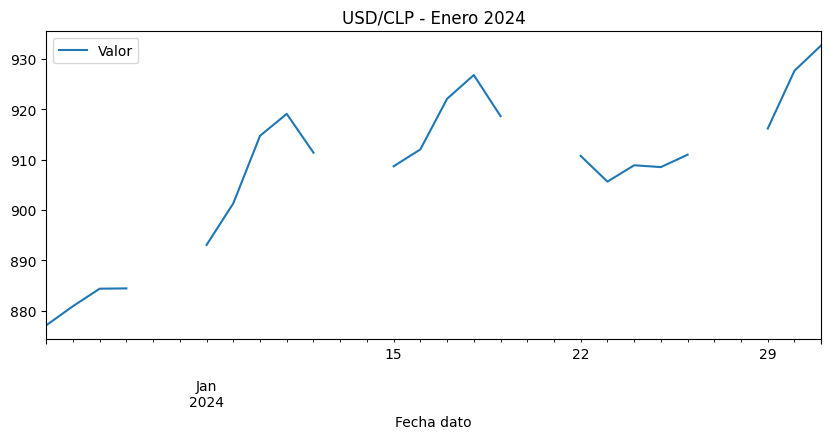

In [11]:

df.plot(x='Fecha dato', y='Valor', figsize=(10, 4), title='USD/CLP - Enero 2024')


In [12]:
""" Funcion Search Series  
SearchSeries
Permite ver la lista de series disponibles por frecuencia y su metadata.

URL: https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx?user=123456789&pass=tuPassword&frequency=frecuenciaelegida&function=SearchSeries

En la cual se consideran los parámetros:

user (obligatorio): completar nombre de usuario.
pass (obligatorio): completar contraseña.
frequency (obligatorio): completar con la frecuencia para la cual se quiere consultar el catálogo de series disponibles. Puede tomar los valores DAILY, MONTHLY, QUARTERLY o ANNUAL.
function (obligatorio): completar valor SearchSeries.
Respuesta: JSON.

"""



search_params = {
    "user": USER,
    "pass": PASSWORD,
    "function": "SearchSeries",
    "frequency": "MONTHLY",
}

response = requests.get(BASE_URL, params=search_params)
response.raise_for_status()
search_data = response.json()

print(f"Código BCCh: {search_data['Codigo']}")
print(f"Llaves del response: {list(search_data.keys())}")

Código BCCh: 0
Llaves del response: ['Codigo', 'Descripcion', 'Series', 'SeriesInfos']


In [13]:
series_monthly = pd.DataFrame(search_data['SeriesInfos'])

print(f"Total de series mensuales: {len(series_monthly)}")
print(f"Columnas disponibles: {series_monthly.columns.tolist()}")
print("\nEjemplo de una serie:")


Seriesipc = series_monthly[
    series_monthly['spanishTitle'].str.contains('IPC', case=False, na=False)]

Seriesipc[['seriesId', 'spanishTitle']].head(20)

Total de series mensuales: 9043
Columnas disponibles: ['seriesId', 'frequencyCode', 'spanishTitle', 'englishTitle', 'firstObservation', 'lastObservation', 'updatedAt', 'createdAt']

Ejemplo de una serie:


,seriesId,spanishTitle
0,G073.IPC.IND.2018.M,"IPC General histórico, índice, BCCh, Base 2018..."
1,G073.IPC.IND.2023.M,"General (empalme BCCh) | IPC Analíticos, índic..."
2,G073.IPC.V12.2018.M,"IPC General histórico, variación mismo período..."
3,G073.IPC.V12.2023.M,"General (empalme BCCh) | IPC Analíticos, varia..."
4,G073.IPC.VAR.2018.M,"IPC General histórico, variación mensual, BCCh..."
5,G073.IPC.VAR.2023.M,"General (empalme BCCh) | IPC Analíticos, varia..."
7,G073.IPCAV.IND.2018.M,"IPC Alimentos volátiles, índice, Base 2018=100"
8,G073.IPCAV.IND.2023.M,"Alimentos volátiles | IPC Analíticos, índice e..."
9,G073.IPCAV.V12.2018.M,"IPC Alimentos volátiles, variación mismo perio..."
10,G073.IPCAV.V12.2023.M,"Alimentos volátiles | IPC Analíticos, variació..."


In [33]:
#Buscar serie de interes (Frecuencia diaria), TPM, F022.TPM.TIN.D001.NO.Z.D debiera aparecer en los resultados
search_params['frequency']= 'DAILY'
respuesta= requests.get(BASE_URL,params=search_params)
respuesta.raise_for_status()
buscar_data_diaria= respuesta.json()

series_diarias= pd.DataFrame(buscar_data_diaria['SeriesInfos'])
series_tpm=series_diarias[series_diarias['spanishTitle'].str.contains('política monetaria')]
series_tpm.head(10)

,seriesId,frequencyCode,spanishTitle,englishTitle,firstObservation,lastObservation,updatedAt,createdAt
715,F022.TPM.TIN.D001.NO.Z.D,DAILY,Tasa de política monetaria (TPM) (porcentaje),Monetary policy rate (MPR) (percentage),07-02-1997,11-05-2026,08-05-2026,08-05-2026
1890,F019.TPM.TIN.10.D,DAILY,"Tasa de interés externa, política monetaria EE...","External interest rate, monetary policy U.S.A.",02-01-1990,05-05-2026,05-05-2026,05-05-2026
1891,F019.TPM.TIN.20.D,DAILY,"Tasa de interés externa, política monetaria Zo...","External interest rate, monetary policy Euro zone",23-12-1998,05-05-2026,05-05-2026,05-05-2026
1892,F019.TPM.TIN.30.D,DAILY,"Tasa de interés externa, política monetaria Japón","External interest rate, monetary policy Japan",31-10-2008,05-05-2026,05-05-2026,05-05-2026
1893,F019.TPM.TIN.ARG.D,DAILY,"Tasa de interés externa, política monetaria Ar...","External interest rate, monetary policy Argentina",17-12-2015,05-05-2026,05-05-2026,05-05-2026
1894,F019.TPM.TIN.AU.D,DAILY,"Tasa de interés externa, política monetaria, A...","External interest rate, monetary policy, Austr...",08-08-1990,05-05-2026,05-05-2026,05-05-2026
1895,F019.TPM.TIN.BRA.D,DAILY,"Tasa de interés externa, política monetaria Br...","External interest rate, monetary policy Brazil",05-03-1999,05-05-2026,05-05-2026,05-05-2026
1896,F019.TPM.TIN.CA.D,DAILY,"Tasa de interés externa, política monetaria, C...","External interest rate, monetary policy, Canada",01-12-1992,05-05-2026,05-05-2026,05-05-2026
1897,F019.TPM.TIN.CHN.D,DAILY,"Tasa de interés externa, política monetaria China","External interest rate, monetary policy China",01-01-1996,30-04-2026,05-05-2026,05-05-2026
1898,F019.TPM.TIN.COL.D,DAILY,"Tasa de interés externa, política monetaria Co...","External interest rate, monetary policy Colombia",13-02-1998,05-05-2026,05-05-2026,05-05-2026


In [50]:
# Buscar serie de interes Tipo de cambio USD/CLP, F073.TCO.PRE.Z.D deberia aparecer en los resultados

coincidencias_usd= series_diarias[series_diarias['spanishTitle'].str.contains('observado')]
coincidencias_usd




,seriesId,frequencyCode,spanishTitle,englishTitle,firstObservation,lastObservation,updatedAt,createdAt
1068,F073.TCO.PRE.Z.D,DAILY,Tipo de cambio nominal (dólar observado $CLP/U...,Nominal exchange rate (Observed dollar $CLP/US...,09-08-1982,11-05-2026,08-05-2026,08-05-2026


In [51]:
# Probar el Cliente BCCh creado como clase

# Setup para que el notebook encuentre src/
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Importar y usar el cliente
from src.client.bcch_client import BCChClient
from datetime import date

client = BCChClient()

# Test 1: USD/CLP (ya conocido)
df_usd = client.get_series("F073.TCO.PRE.Z.D", date(2024, 1, 1), date(2024, 1, 31))
print("USD/CLP, primeras filas:")
print(df_usd.head())


USD/CLP, primeras filas:
       fecha   valor
0 2024-01-02  877.12
1 2024-01-03  880.92
2 2024-01-04  884.39
3 2024-01-05  884.45
4 2024-01-06     NaN


In [52]:
# Test 2: catálogo mensual
catalog = client.search_series("MONTHLY")
print(f"\nTotal series mensuales en catálogo: {len(catalog)}")


Total series mensuales en catálogo: 9043


In [53]:
# Test 3: validar manejo de errores con un código inválido
try:
    client.get_series("SERIE_QUE_NO_EXISTE", date(2024, 1, 1), date(2024, 1, 31))
except RuntimeError as e:
    print(f"\n✓ Error manejado correctamente: {e}")


✓ Error manejado correctamente: Error BCCh (código -50): An internal error has occurred, information is not available.
